In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\nu_beta_effects'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

In [6]:
import sys  
sys.path.insert(1,stvelo_path)
from pipelines.simulations_3ode_class_v1 import Simulation3ODE
from pipelines.metrics import *
from pipelines.preprocessing import Preprocessing
from pipelines.compute_velocity_scaling import Velocities
from pipelines.utils import proportions_nuc_cyto

In [49]:
# Order of correlations: [rho_alpha_beta, rho_alpha_nu, rho_alpha_gamma, rho_beta_nu, rho_beta_gamma, rho_nu_gamma]
# Order of sigmas : [sigma_log_alpha, sigma_log_beta, sigma_log_nu, sigma_log_gamma]
# Order of means : [alpha,beta,nu,gamma]

# config_simulation = {'parameters':{ 'n_obs':1000,
#     'n_vars':400,
#     'alpha':5,
#     'beta':0.02,
#     'nu' :0.33,
#     'gamma':0.32,
#     'alpha_':0,
#     't_max':20,
#     'noise_model':"normal",
#     'noise_level':2,
#     }, 

#     'options': {'generate_parameters':False,
#                 'generate_switch_times':True,
#                   'save':False,
#                   'saving_path':None
#                   },
#     }
config_simulation= {'parameters':{ 'n_obs':3000,
    'n_vars':600,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':20,
    'noise_model':"normal",
    'noise_level':3,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                'lower_bound':0.05,
                'upper_bound':0.6,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':[0.4, 0.3, 0.2, 0.2, -0.1, -0.1],
    'sd':[6*0.4, 0.5*0.5, 0.77*0.4, 0.51*0.5],
    'mean':[6,0.5,0.77,0.51]} }

config_preprocessing = {'preprocess_params': {
     'min_counts': 200, 
     'min_cells': 5,
     'min_shared_count':10,
     'enforce':False,
     'n_top_genes':None,
     'n_neighbors': 20,
     'n_pcs': 20,
     'min_dist': 1,
     'resolution':1},
'functions_to_apply': {'filter_cells':    False, 
                       'filter_genes':    False, 
                       'normalize_total': False,
                       'log1p': False,
                       'use_scv':True,
                       'pca': True,
                       'neighbors': True,
                       'umap': True,
                       'leiden': True,
                       'moments': True}}


# config_velocity = { 'velocity_types': ['dynamical','deterministic','stochastic','velovi']}
config_velocity = { 'velocity_types': ['deterministic','stochastic','dynamical','velovi'],
                   'velovi_model_params':{'n_hidden':32,
                                    'n_latent':5,
                                    'n_layers':1,
                                    },
                    'velovi_train_params': {'epochs':500,
                                            'lr':0.01,
                                            'weight_decay':0.01,
                                            'early_stop':True,
                                            'batch_size':16},
                     'velovi_getting_parameters':{'t_max' :20 ,
                                           'n_samples':15}}



config_plotting = {
    'colorsets': ['leiden', 'clusters'],
    'velocity_embedding_stream': True,
    'velocity_embedding_grid': True,
    'velocity_embedding': True,
    'rank_velocity_genes': True,
    'velocity_confidence': True,
    'velocity_length': True
}



In [50]:
config_preprocessing = {'preprocess_params': {
     'min_counts': 200, 
     'min_cells': 5,
     'min_shared_count':10,
     'enforce':False,
     'n_top_genes':None,
     'n_neighbors': 15,
     'n_pcs': 0,
     'min_dist': 0.5,
     'resolution':1},
'functions_to_apply': {'filter_cells':    True, 
                       'filter_genes':    True, 
                       'normalize_total': True,
                       'log1p': True,
                       'use_scv':False,
                       'pca': True,
                       'neighbors': True,
                       'umap': True,
                       'leiden': True,
                       'moments': True}}

# Simulation 

In [51]:
simulator = Simulation3ODE(config= config_simulation)
adata_dict = simulator.simulation()

mean values of [alpha,beta,nu,gamma]:[6, 0.5, 0.77, 0.51]
parameters for 600 genes,  generated with the covariance matrix: [[ 0.14842001  0.07696104  0.04688359  0.03922071]
 [ 0.07696104  0.22314355  0.03922071 -0.02531781]
 [ 0.04688359  0.03922071  0.14842001 -0.02020271]
 [ 0.03922071 -0.02531781 -0.02020271  0.22314355]]
5.9229219552242895
0.4942521614950781
0.7587987660048586
0.499401671615695


In [52]:
adatas = {k:v.copy() for k,v in adata_dict.items()}
ada = {k:v.copy() for k,v in adata_dict.items()}

In [32]:
import scanpy as sc
import matplotlib.pyplot as plt

In [15]:
saving_path = os.path.join(os.getcwd(),'outputs','plots','noise_moment')

In [73]:
noise = '2'
for i in [0,10,30,50,70]:
    n= str(i)
    if i==0:
        scv.pl.scatter(ada['adata_n_c_3000obs_600genes'],color="true_t", basis=['0'], ncols=5, frameon=False,dpi=20,xlabel='cytoplasmic', ylabel='nucleic',show=False)
        plt.savefig(os.path.join(saving_path, f'{noise}_{n}'))
        plt.close()
    else:
        sc.pp.neighbors(ada['adata_n_c_3000obs_600genes'],n_neighbors=i)
        scv.pp.moments(ada['adata_n_c_3000obs_600genes'], n_pcs=None,n_neighbors=None)
        scv.pl.scatter(ada['adata_n_c_3000obs_600genes'],color="true_t", basis=['0'], ncols=5, frameon=False,dpi=20,xlabel='cytoplasmic', ylabel='nucleic',show=False)
        plt.savefig(os.path.join(saving_path, f'{noise}_{n}'))
        plt.close()



computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [77]:
sc.pp.neighbors(ada['adata_n_c_3000obs_600genes'],n_neighbors=20)

In [93]:
a = ada['adata_n_c_3000obs_600genes'].obsp['connectivities']

In [97]:
print(a.toarray())

[[0.         0.08071155 0.10611089 ... 0.         0.         0.        ]
 [0.08071155 0.         0.         ... 0.         0.         0.        ]
 [0.10611089 0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [47]:
sc.pp.log1p(ada['adata_n_c_2000obs_600genes'])

c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


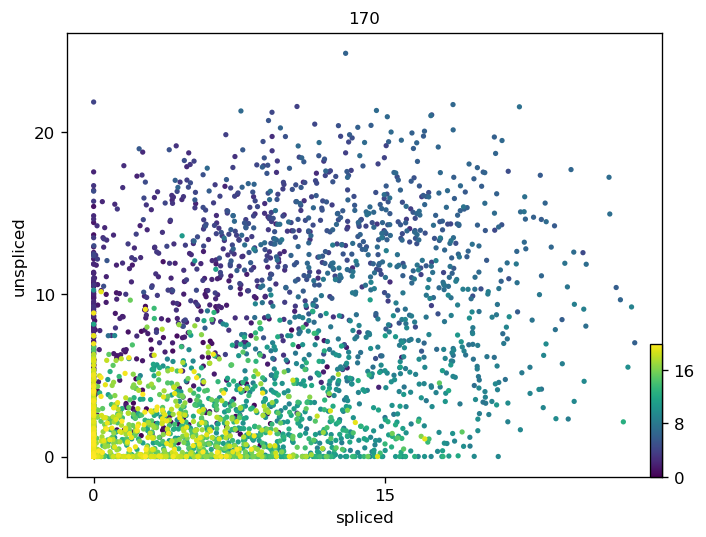

In [53]:
scv.pl.scatter(ada['adata_n_c_3000obs_600genes'],color="true_t", basis=['170'], ncols=5, frameon=True,dpi=120)

In [117]:
adata_dict

{'adata_s_u_1000obs_400genes': AnnData object with n_obs × n_vars = 1000 × 400
     obs: 'true_t'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity',
 'adata_n_c_1000obs_400genes': AnnData object with n_obs × n_vars = 1000 × 400
     obs: 'true_t'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity'}

In [13]:
import scanpy as sc

In [48]:
for k , adata in adata_dict.items():
    adata.X= adata.layers['spliced']


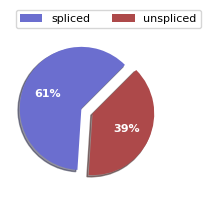

In [54]:
scv.pl.proportions(adata_dict['adata_s_u_3000obs_600genes'])

<Axes: >

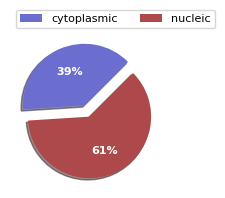

In [55]:
proportions_nuc_cyto(adata_dict['adata_n_c_3000obs_600genes'])

# Preprocessing 

In [56]:
for key, adata in adata_dict.items():
    print(f'{key} is being preprocessed.')
    preprocessor = Preprocessing(adata,config_preprocessing)
    adata = preprocessor.preprocess_data()

adata_s_u_3000obs_600genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_3000obs_600genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


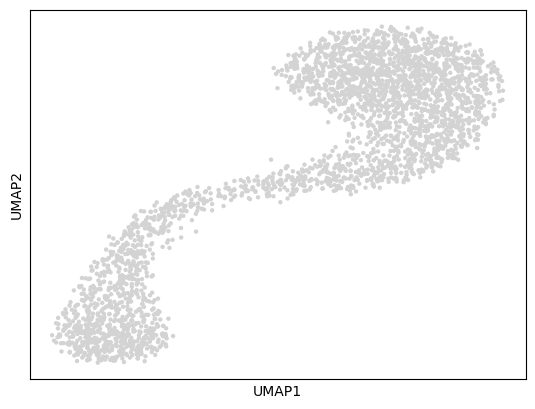

In [57]:
sc.pl.umap(adata_dict['adata_n_c_3000obs_600genes'])

In [232]:
def elementwise_covariance_numpy(A, B):
    """
    Compute covariance between corresponding columns of two NumPy matrices.

    Parameters:
    A (np.ndarray): First matrix (n_samples x n_features)
    B (np.ndarray): Second matrix (n_samples x n_features)

    Returns:
    np.ndarray: 1D array of covariance values for each corresponding column pair
    """
    if A.shape != B.shape:
        raise ValueError("Matrices must have the same shape.")
    
    covariances = []
    for i in range(A.shape[1]):
        cov = np.cov(A[:, i], B[:, i], ddof=1)[0, 1]
        covariances.append(cov)
    return np.array(covariances)


In [68]:
scv.tl.velocity(ada['adata_n_c_2000obs_600genes'],mode='deterministic',perc=[5,95])

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [65]:
scv.tl.velocity_graph(ada['adata_s_u_2000obs_600genes'])

computing velocity graph (using 1/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


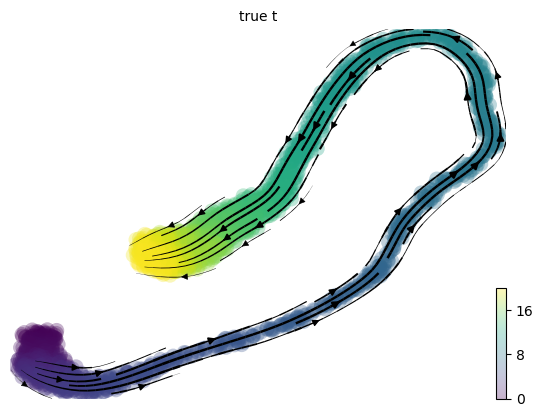

In [66]:
scv.pl.velocity_embedding_stream(ada['adata_s_u_2000obs_600genes'],color='true_t')

In [25]:
scv.tl.velocity(adata_dict['adata_n_c_2000obs_600genes'],mode='deterministic',perc=[5,95],min_r2=-0.2)

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [77]:
scv.tl.recover_dynamics(ada['adata_n_c_2000obs_600genes'])

recovering dynamics (using 1/24 cores)
    finished (0:00:44) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [90]:
scv.tl.velocity(ada['adata_n_c_2000obs_600genes'],mode ='dynamical',min_r2=-0.3)

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [26]:
adata_dict['adata_n_c_2000obs_600genes'].var['velocity_genes'].value_counts()

velocity_genes
True     463
False    137
Name: count, dtype: int64

In [128]:
scv.tl.velocity(adatas['adata_n_c_1000obs_400genes'],mode ='deterministic')

computing velocities
The correlation threshold has been reduced to -1.2745.
Please be cautious when interpreting results.
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [ ]:
ada['adata_n_c_000obs_600genes'].var['velocity_genes'].value_counts()

velocity_genes
True     426
False    174
Name: count, dtype: int64

In [66]:
adata_dict['adata_n_c_2000obs_600genes'].var['velocity_genes'].value_counts()

velocity_genes
True     460
False    140
Name: count, dtype: int64

In [173]:
ada['adata_n_c_3000obs_600genes'].var['velocity_genes'].value_counts()

velocity_genes
False    304
True     296
Name: count, dtype: int64

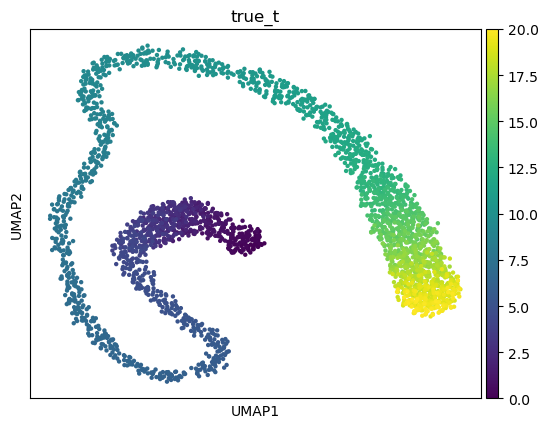

In [182]:
import scanpy as sc
# sc.pl.umap(adata_dict['adata_s_u_1000obs_400genes'],color= 'true_t')
# sc.pl.umap(adatas['adata_s_u_1000obs_400genes'],color= 'true_t')
sc.pl.umap(ada['adata_s_u_3000obs_600genes'],color= 'true_t')

In [129]:
ada['adata_n_c_1000obs_400genes'].var['true_alpha'].mean()

9.951522208287436

c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


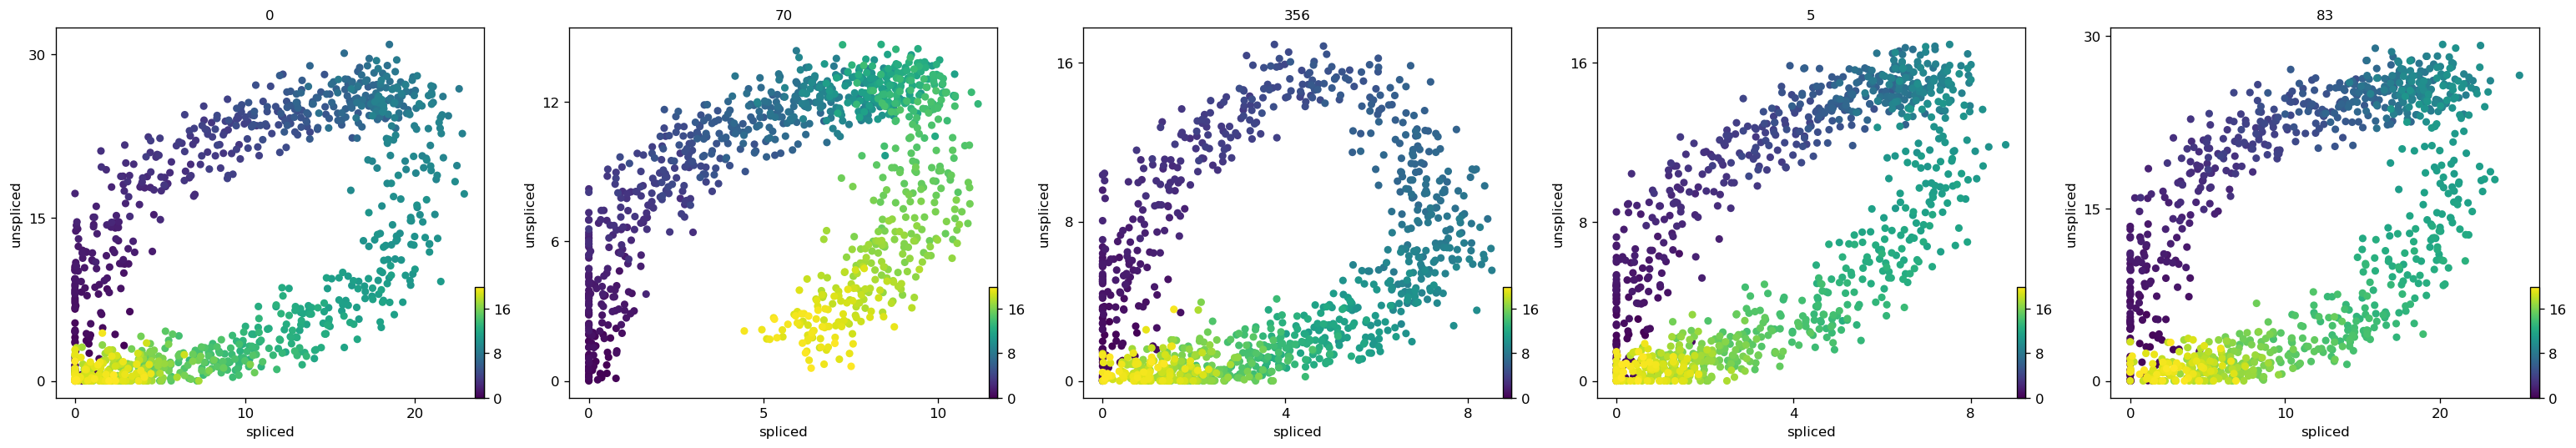

In [49]:
# scv.pl.scatter(adata_dict['adata_n_c_1000obs_400genes'],color="true_t", basis=['0','70','398','318','83'], ncols=5, frameon=True,dpi=120) # normalized 
# scv.pl.scatter(adatas['adata_n_c_1000obs_400genes'],color="true_t", basis=['0','70','398','318','83'], ncols=5, frameon=True,dpi=120) # not normalized scanpy
scv.pl.scatter(ada['adata_n_c_1000obs_400genes'],color="true_t", basis=['0','70','356','5','83'], ncols=5, frameon=True,dpi=120)

# Velocity 

In [58]:
velocity_computer = Velocities(adata_dict,config_velocity)

Using device: cuda


In [59]:
adata_dict_velocity = velocity_computer.compute_velocities()

deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:20) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities


c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\tools\optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 8/24 cores)
    finished (0:00:51) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
dynamical velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:18) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
adata_s_u_3000obs_600genes 0.01
0.01
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
min_max_scaler is working!


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 211/500:  42%|████▏     | 211/500 [11:12<15:21,  3.19s/it, v_num=1, train_loss_step=431, train_loss_epoch=436]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 425.168. Signaling Trainer to stop.
computing velocity graph (using 12/24 cores)
    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
t_max:20
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities


...

    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 8/24 cores)
    finished (0:00:42) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
dynamical velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)


GPU available: True (cuda), used: True


    finished (0:00:16) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
adata_n_c_3000obs_600genes -0.2
-0.2
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
min_max_scaler is working!


TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 405/500:  81%|████████  | 405/500 [21:00<04:55,  3.11s/it, v_num=1, train_loss_step=385, train_loss_epoch=389]    
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 374.766. Signaling Trainer to stop.
computing velocity graph (using 12/24 cores)
    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
t_max:20


In [24]:
adata_dict

{'adata_s_u_2000obs_600genes': AnnData object with n_obs × n_vars = 2000 × 600
     obs: 'true_t', 'n_counts', 'leiden'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
     uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity', 'Ms', 'Mu'
     obsp: 'distances', 'connectivities',
 'adata_n_c_2000obs_600genes': AnnData object with n_obs × n_vars = 2000 × 600
     obs: 'true_t', 'n_counts', 'leiden'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
     uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity', 'Ms', 'Mu'
     obsp: 'distances', 'connectivities'}

In [46]:
adata_dict_velocity[1]['adata_s_u_3000obs_600genes_velovi'].var['velocity_genes'].value_counts()

velocity_genes
True    282
Name: count, dtype: int64

In [ ]:
adata_dict_velocity['adata_s_u_1000obs_400genes_deterministic'].var['velocity_genes'].value_counts()

velocity_genes
True     241
False    159
Name: count, dtype: int64

In [66]:
adata_dict_velocity[1]['adata_s_u_3000obs_600genes_dynamical'].var['velocity_genes'].value_counts()

velocity_genes
False    329
True     271
Name: count, dtype: int64

c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


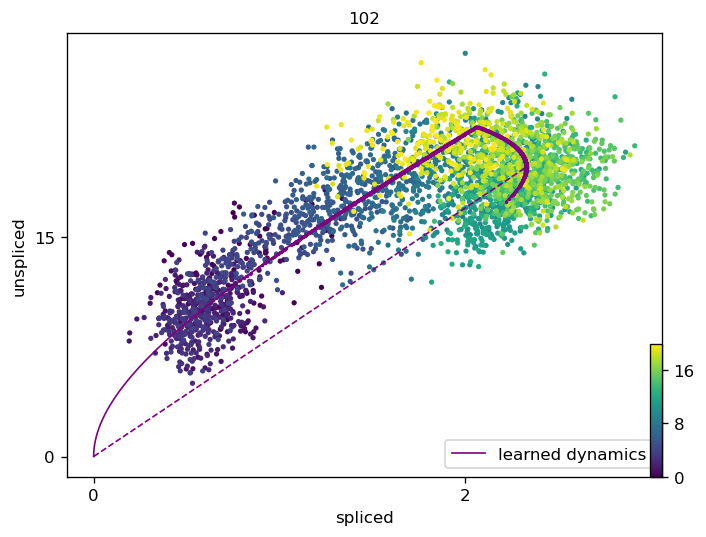

In [70]:
scv.pl.scatter(adata_dict_velocity[1]['adata_n_c_3000obs_600genes_velovi'],color="true_t", basis=['102'], ncols=5, frameon=True,dpi=120)

# Save adatas 

In [47]:
os.getcwd()

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github'

In [71]:
os.getcwd()

saving_path = os.path.join(os.getcwd(),'data','noise3')
saving_path_vae = os.path.join(os.getcwd(),'data','vae')

vae = adata_dict_velocity[0]

np.save(os.path.join(saving_path_vae,'noise3'), vae) 


adata_dict = adata_dict_velocity[1]

for d in adata_dict.keys():
    print(d)
    adata_dict[d].write(os.path.join(saving_path,d+'.h5ad'))

adata_s_u_3000obs_600genes_deterministic
adata_s_u_3000obs_600genes_stochastic
adata_s_u_3000obs_600genes_dynamical
adata_s_u_3000obs_600genes_velovi
adata_n_c_3000obs_600genes_deterministic
adata_n_c_3000obs_600genes_stochastic
adata_n_c_3000obs_600genes_dynamical
adata_n_c_3000obs_600genes_velovi


In [156]:
adata_dict = adata_dict_velocity[1]

In [154]:
for key, adata in ada.items():
    true_beta = adata.var['true_beta']
    true_nu = adata.var['true_nu']
    true_gamma = adata.var['true_gamma']
    if 's_u' in key:
        true_ratio = (1/true_beta )* (1/((1/true_gamma)+(1/true_nu)))
    else:
        true_ratio = true_gamma*((1/true_nu)+(1/true_beta))
    adata.var['true_ratio'] = true_ratio

In [25]:
from scipy.stats import pearsonr

In [ ]:
a = adata_dict['adata_n_c_1000obs_400genes_deterministic'].var['true_ratio']
b = adata_dict['adata_n_c_1000obs_400genes_deterministic'].var['velocity_gamma']

In [72]:
read_dictionary = np.load('data/vae/beta_small_2.npy',allow_pickle='TRUE').item()
vae = read_dictionary['adata_n_c_1000obs_400genes_velovi']

In [73]:
a = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_ratio']
b = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_gamma']/ adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_beta']
c= vae.get_rates()["gamma"]/vae.get_rates()["beta"]

In [70]:
a

0       8.757527
1      11.555471
2      21.843635
3      15.766281
4      25.717385
         ...    
395    10.900884
396    33.162423
397    15.926322
398    28.045873
399    26.589988
Name: true_ratio, Length: 400, dtype: float64

In [76]:
cor = pearsonr(a,b)

In [77]:
cor[0]

0.14412185027750746

In [44]:
min(adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_t_'])

1.5953572372203986

In [58]:
latent_time = read_dictionary['adata_n_c_1000obs_400genes_velovi'].get_latent_time(n_samples=25)

In [67]:
scaling = 30 / latent_time.max(0)
scaling = np.array(scaling)

In [84]:
latent_time.max(0)

0       7.132499
1      11.336309
2       8.704609
3      11.554673
4       7.637457
         ...    
395     6.589297
396     7.493535
397     6.259007
398     6.914904
399    12.180807
Length: 400, dtype: float32

# True Velocity 

In [55]:
adata_dict['adata_n_c_1000obs_400genes']

AnnData object with n_obs × n_vars = 1000 × 400
    obs: 'true_t'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
    layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity'